#### Short notebook to demonstrate changing the scales in the BluebirdATC radar display


This is very lightly modified from the `agent_demo.ipynb` notebook and uses the helper functions from there for the Y sector, but any other sector works the same. 

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import typing

from enum import Enum

import IPython.display
import matplotlib.pyplot as plt

from bluebird_gymnasium.envs import BaseEnv, SectorIEnv, SectorXEnv, SectorYEnv, SpringfieldEnv

### Helper functions

In [3]:
# helper function to define all supported actions in this notebook as a Python `Enum`.

def actions_to_enum(env: BaseEnv) -> Enum:
    actions_map = env.get_action_parser().action_formatter_map
    new_actions_map = {}

    for action_int, action_name in actions_map.items():
        ret = action_name.split("__")

        if len(ret) == 1:
             # for actions without a value/magnitude
            # e.g., no operation (noop), route direct
            base_name = ret[0]
            magnitude = None
        elif len(ret) == 2:
            # other actions that include magnitude
            # e.g., left turn, right turn etc.
            base_name, magnitude = ret

        enum_name = None
        if base_name == "action_noop":
            enum_name = "NOOP"
        elif base_name == "simple_heading_left":
            enum_name = "LEFT"
        elif base_name == "simple_heading_right":
            enum_name = "RIGHT"
        elif base_name == "simple_fl_descent":
            enum_name = "DESCEND"
        elif base_name == "simple_fl_climb":
            enum_name = "CLIMB"
        else:
            raise ValueError(f"action `{base_name}` is not supported")

        if magnitude is not None:
            enum_name = "_".join([enum_name, magnitude])

        new_actions_map[enum_name] = action_int

    return Enum("Actions", list(new_actions_map.items()))


### State-Action-Reward configs

In [4]:
DIFFICULTY_LEVEL_1 = 1 # easy: 1 aircraft, overflier (no flight level change)
DIFFICULTY_LEVEL_2 = 2 # medium: 2 aircraft, overfliers (no flight level change)
DIFFICULTY_LEVEL_3 = 3 # hard: 3 - 5 aircraft, overfliers (no flight level change)

def default_state_representation_config() -> dict[str, typing.Union[str, int]]:
    return {
        "encoder_cls": "extra_minimal",
        "k_nearest_aircraft": 1,
    }
    return config

def default_action_config(lateral: bool=True, vertical: bool=False) -> dict[str, bool]:
    if not (lateral or vertical):
        raise ValueError("Ensure `lateral`, `vertical`, or both are set to True")

    return {
        "simple_heading_left": lateral, # turn left 10 degrees
        "simple_heading_right": lateral, # turn right 10 degrees
        "simple_fl_climb": vertical, # go up 10 flight levels
        "simple_fl_descent": vertical, # go down 10 flight levels
        "simple_fl_exit": vertical, # go up or down to the exit flight level
    }

def default_reward_config() -> dict[str, list[typing.Union[str, float]]]:
    return {
        "fns": [
            "position_status_const",
            "lateral_centreline_distance_shaped",
            "safety_simple_avoidance_exp"
        ],
        "coeffs": [1.0, 1.0, 1.2],
    }


def get_scenario_sector_y(
    difficulty: int,
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = SectorYEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # sector config
    config.airspace_config["fl_limits"] = [200, 220]

    # scenario config
    if difficulty == DIFFICULTY_LEVEL_1: num_aircraft = 1
    elif difficulty == DIFFICULTY_LEVEL_2: num_aircraft = 2
    elif difficulty == DIFFICULTY_LEVEL_3: num_aircraft = random.choice(range(3, 5))
    else: raise ValueError("Difficulty level not supported")

    config.scenario_config["cls"] = "tactical"
    config.scenario_config["args"] = {
        "num_aircraft": num_aircraft,
        "balance": [0.0, 0.0, 1.0],
    }

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}
    
    return config


### Default behaviour 

The sector is shown in degrees longitude and latitude and spines (scales) are not shown.

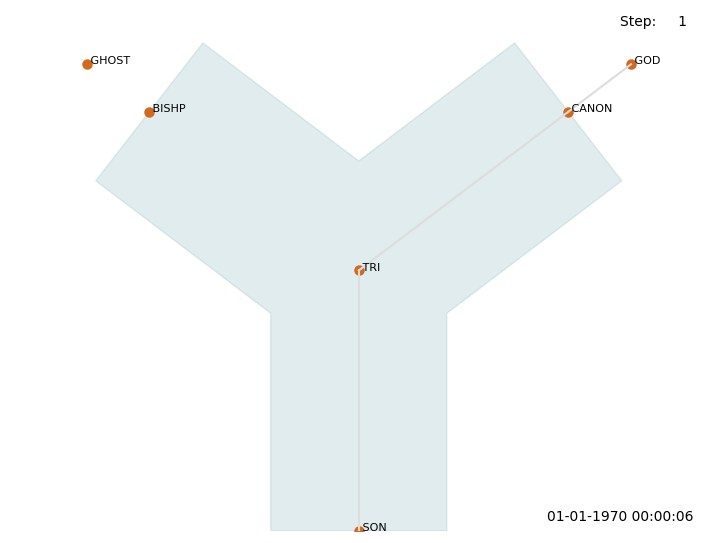

In [5]:
# instantiate a scenario
config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())
    break
    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)


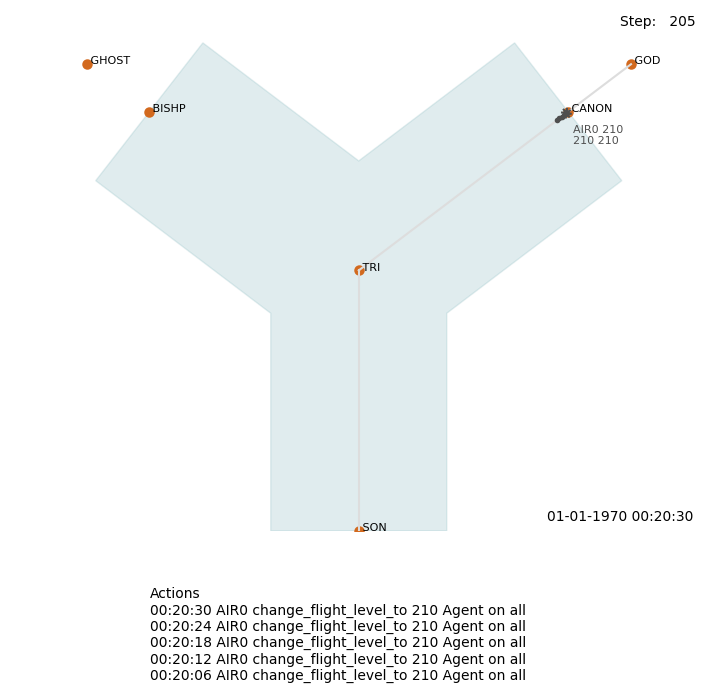

In [6]:
config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=True)
config.radar_config["display_actions"] = True
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {"AIR0": 5} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

### With scales


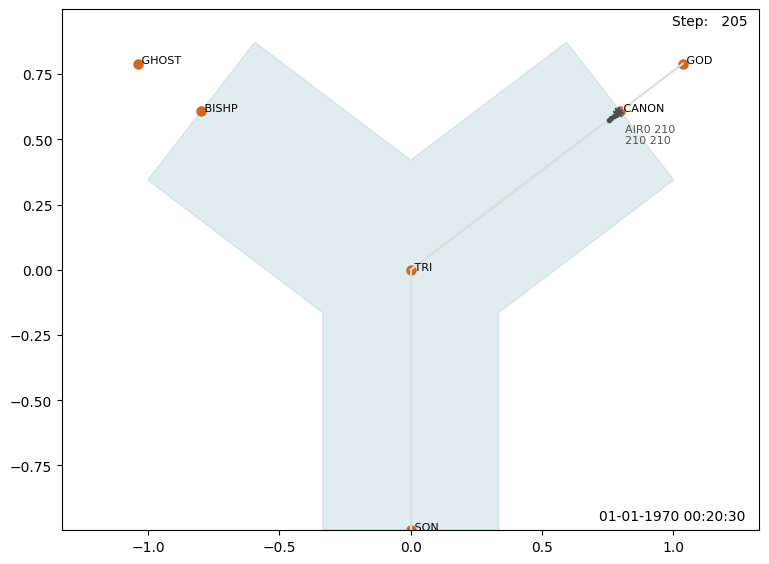

In [7]:
config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
config.radar_config["show_spines"] = True
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

### Use the standard projection with units of nautical miles

Note that the Y sector is on the equator, leading to very large negative values for the latitude.  The figure is scaled (`axis("scaled")`) so that circles are drawn as circles.  Change `"NM"` to `"km"` to set the units to be kilometres.

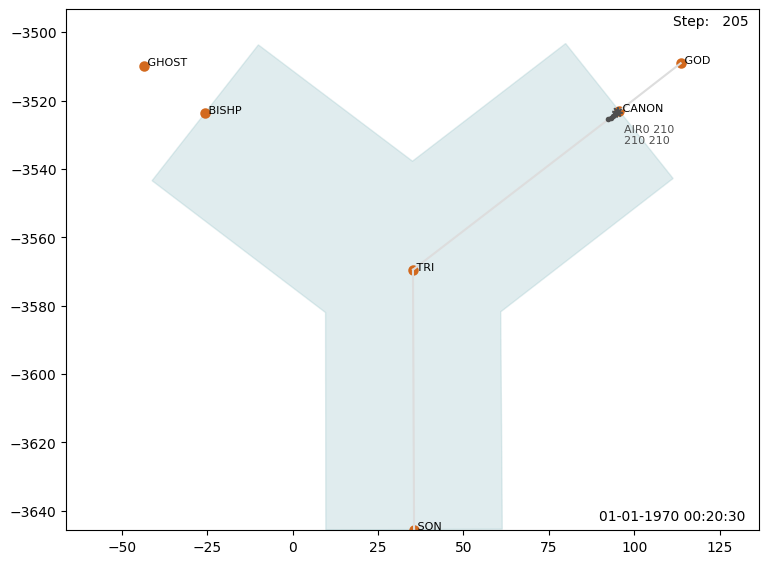

In [8]:
config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
config.radar_config["show_spines"] = True
config.radar_config["display_units"] = "nm"
config.radar_config["scaled"] = True
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    #ax = plt.gca()
    #ax.grid()
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)


Demo of user-defined transformation.  Here, just swap latitude and longitude. 

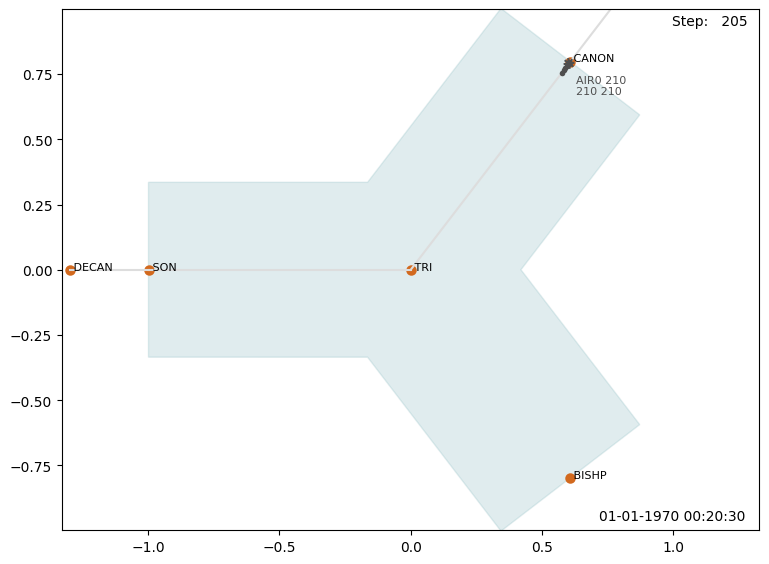

In [9]:
def swap_lonlat(lon, lat):
    return lat, lon

config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
config.radar_config["show_spines"] = True
config.radar_config["display_units"] = swap_lonlat
#config.radar_config["scaled"] = True
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    #ax = plt.gca()
    #ax.grid()
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)
